## Import Data


In [3]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split,GridSearchCV
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 71.3 MB/s eta 0:00:00ta 0:00:01


## Data reduction due to large number of dataset


In [17]:
import dask.dataframe as dd

# pd.options.display.float_format = '{:.2f}'.format
df = pd.read_parquet('./yellow_tripdata_2022-01.parquet')
# df.isnull().sum()
df_cleaned = df.dropna(subset=['passenger_count','RatecodeID','store_and_fwd_flag','congestion_surcharge','airport_fee'])
print(len(df))
# Randomly sample 25,000 rows
reduced_df = df_cleaned.sample(n=25000, random_state=42)

# df_cleaned = df.dropna()
# print(len(reduced_df))
# df.isnull().sum()

# # print(len(df))
# ddf = dd.from_pandas(rows_with_nulls, npartitions=10)
# total_rows = len(df_cleaned)
# # print(fraction)
# reduced_df = ddf.sample(frac=0.1, random_state=42).compute()
# if len(reduced_df) > 25000:
#     reduced_df = reduced_df.sample(n=25000, random_state=42)
# reduced_df.to_csv('./reduced_dataset.csv', index=False)
# print(len(reduced_df))
reduced_df.info()

2463931
<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               25000 non-null  int64         
 1   tpep_pickup_datetime   25000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  25000 non-null  datetime64[us]
 3   passenger_count        25000 non-null  float64       
 4   trip_distance          25000 non-null  float64       
 5   RatecodeID             25000 non-null  float64       
 6   store_and_fwd_flag     25000 non-null  object        
 7   PULocationID           25000 non-null  int64         
 8   DOLocationID           25000 non-null  int64         
 9   payment_type           25000 non-null  int64         
 10  fare_amount            25000 non-null  float64       
 11  extra                  25000 non-null  float64       
 12  mta_tax                25000 non-null  float64    

## Describe data

In [8]:
reduced_df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,25000.00000,25000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,1.69764,2022-01-17 00:58:38.527959,2022-01-17 01:13:20.625520,1.395480,3.115978,1.447000,166.161400,164.013840,1.231960,12.669806,1.031924,0.491320,2.365824,0.373600,0.296736,18.880993,2.280500,0.082250
min,1.00000,2022-01-01 00:10:16,2022-01-01 00:18:13,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-200.000000,-4.500000,-0.500000,0.000000,-18.000000,-0.300000,-190.300000,-2.500000,-1.250000
25%,1.00000,2022-01-09 13:55:12.500000,2022-01-09 14:03:44,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,11.300000,2.500000,0.000000
50%,2.00000,2022-01-17 09:21:21,2022-01-17 09:31:18,1.000000,1.730000,1.000000,162.000000,162.000000,1.000000,9.000000,0.500000,0.500000,2.000000,0.000000,0.300000,14.300000,2.500000,0.000000
75%,2.00000,2022-01-24 13:03:19.750000,2022-01-24 13:20:04.750000,1.000000,3.100000,1.000000,234.000000,236.000000,1.000000,13.500000,2.500000,0.500000,3.000000,0.000000,0.300000,19.800000,2.500000,0.000000
max,2.00000,2022-02-01 03:30:04,2022-02-01 06:01:41,6.000000,89.400000,99.000000,265.000000,265.000000,4.000000,330.000000,8.250000,0.500000,86.000000,32.500000,0.300000,413.010000,2.500000,1.250000
std,0.45929,NaN,NaN,0.984558,4.158916,6.162213,64.770926,70.520164,0.460959,12.077320,1.237176,0.082734,2.754190,1.679861,0.043889,15.024932,0.745045,0.312332


## Data Preprocessing / Transformation
### Feature Engineering - pickup datetime

1) The dataset has columns "pep_pickup_datetime" "tpep_dropoff_datetime" for that creatig new column Time slot with (Morning,Evening,night,afternoon) for better analysis using ColumnTransformer

2) Creating a separate column which has the data for trip distance (short, long, medium)
but the the column has outliers in it and random values like 300,000 miles 
so creating a caping thershold 278 miles because one rows has 277 miles with correct data 

## Feature Engineering - trip distance
- (short, medium, long )

## Create duration column

In [18]:
reduced_df['duration'] = (reduced_df['tpep_dropoff_datetime'] - reduced_df['tpep_pickup_datetime'])/np.timedelta64(1,'m')
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               25000 non-null  int64         
 1   tpep_pickup_datetime   25000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  25000 non-null  datetime64[us]
 3   passenger_count        25000 non-null  float64       
 4   trip_distance          25000 non-null  float64       
 5   RatecodeID             25000 non-null  float64       
 6   store_and_fwd_flag     25000 non-null  object        
 7   PULocationID           25000 non-null  int64         
 8   DOLocationID           25000 non-null  int64         
 9   payment_type           25000 non-null  int64         
 10  fare_amount            25000 non-null  float64       
 11  extra                  25000 non-null  float64       
 12  mta_tax                25000 non-null  float64       
 13 

## Three important column to predict outliers are
- trip_distance
- fare_amount
- duration

### Visualizing

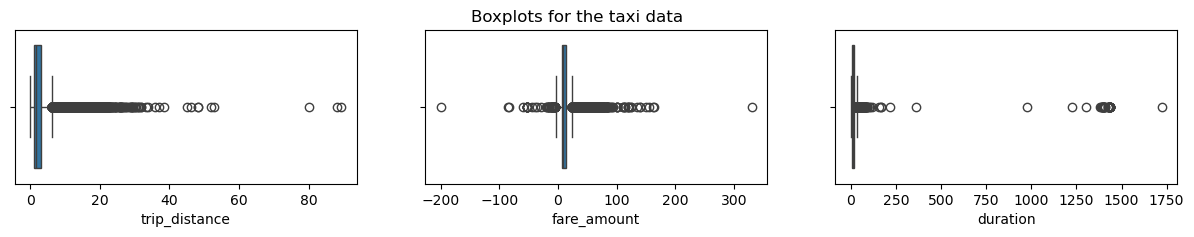

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for the taxi data')
sns.boxplot(ax=axes[0], x=reduced_df['trip_distance'])
sns.boxplot(ax=axes[1], x=reduced_df['fare_amount'])
sns.boxplot(ax=axes[2], x=reduced_df['duration'])
plt.show();

## The trip distance column outliers
- the trip distance column have 532 zero values out of 25000 which will not have a huge impact on datset so the trip distance column remains same

In [20]:
sorted(set(reduced_df['trip_distance']))[:10]

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

In [21]:
sum(reduced_df['trip_distance']==0)

284

## Fare amount outlier

In [22]:
reduced_df['fare_amount'].describe()
Q1 = reduced_df['fare_amount'].quantile(0.25)
Q3 = reduced_df['fare_amount'].quantile(0.75)
# Compute the IQR
IQR = Q3 - Q1
print(Q3+(4*IQR))
print(f"IQR for fare_amount: {IQR}")
# reduced_df['fare_amount'].describe()


41.5
IQR for fare_amount: 7.0


In [23]:
def oulierDetect(name_list,factor):
    for x in name_list:
        # if values less than zeros are considered as zeros
        reduced_df.loc[reduced_df[x] < 0, x] = 0
        # seting q3 value
        q3 = reduced_df[x].quantile(0.75)
        # setting the upper cap
        upper_cap = q3 + (factor * (q3 - reduced_df[x].quantile(0.25)))
        
        reduced_df.loc[reduced_df[x] > upper_cap, x] = upper_cap


In [24]:
oulierDetect(['fare_amount'], 6)
reduced_df['fare_amount'].describe()

count    25000.000000
mean        12.587528
std         10.884256
min          0.000000
25%          6.500000
50%          9.000000
75%         13.500000
max         55.500000
Name: fare_amount, dtype: float64

## Duration Outlier detection
- changeing the factor to 4 for better predictions

In [25]:
reduced_df.loc[reduced_df['duration'] < 0, 'duration'] = 0
reduced_df['duration'].min()

0.0

In [27]:
oulierDetect(['duration'], 6)
reduced_df['duration'].describe()


count    25000.000000
mean        12.805615
std          9.871953
min          0.000000
25%          6.350000
50%         10.166667
75%         16.133333
max         74.833333
Name: duration, dtype: float64

In [29]:
oulierDetect(['trip_distance'],14)
reduced_df['trip_distance'].describe()

count    25000.000000
mean         3.104659
std          4.027286
min          0.000000
25%          1.050000
50%          1.730000
75%          3.100000
max         31.800000
Name: trip_distance, dtype: float64

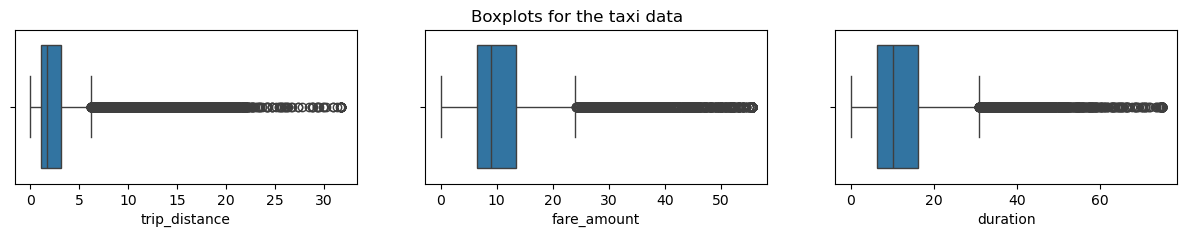

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for the taxi data')
sns.boxplot(ax=axes[0], x=reduced_df['trip_distance'])
sns.boxplot(ax=axes[1], x=reduced_df['fare_amount'])
sns.boxplot(ax=axes[2], x=reduced_df['duration'])
plt.show();

In [31]:
reduced_df['pickDrop'] = reduced_df['PULocationID'].astype(str) + ' ' + reduced_df['DOLocationID'].astype(str)
reduced_df['pickDrop'].head(2)

1298294    233 141
469658      48 186
Name: pickDrop, dtype: object

## Mean Distance Column

In [32]:
pickDrop_Dis = reduced_df.groupby('pickDrop').mean(numeric_only=True)[['trip_distance']]
pickDrop_Dis[:10]

pickDrop_Dis_dict = pickDrop_Dis.to_dict()


pickDrop_Dis_dict = pickDrop_Dis_dict['trip_distance']

# len(pickDrop_Dis_dict)

reduced_df['mean_dis'] = reduced_df['pickDrop']


reduced_df['mean_dis'] = reduced_df['mean_dis'].map(pickDrop_Dis_dict)


reduced_df[(reduced_df['PULocationID']==100) & (reduced_df['DOLocationID']==231)][['mean_dis']]

,mean_dis
905168,3.357143
1526413,3.357143
1270028,3.357143
37591,3.357143
1390900,3.357143
1750897,3.357143
2085901,3.357143


## Mean Duriation Column

In [33]:
grouped = reduced_df.groupby('pickDrop').mean(numeric_only=True)[['duration']]
grouped

grouped_dict = grouped.to_dict()
grouped_dict = grouped_dict['duration']

reduced_df['mean_duration'] = reduced_df['pickDrop']
reduced_df['mean_duration'] = reduced_df['mean_duration'].map(grouped_dict)

reduced_df[(reduced_df['PULocationID']==100) & (reduced_df['DOLocationID']==231)][['mean_duration']]

,mean_duration
905168,19.490476
1526413,19.490476
1270028,19.490476
37591,19.490476
1390900,19.490476
1750897,19.490476
2085901,19.490476


In [34]:

reduced_df['dd'] = reduced_df['tpep_pickup_datetime'].dt.day_name().str.lower()

reduced_df['mm'] = reduced_df['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

reduced_df['dd']

1298294      tuesday
469658        friday
1188324       monday
1508389       friday
824431     wednesday
             ...    
2301695       sunday
1644570     saturday
616078        sunday
2206717       friday
338650      thursday
Name: dd, Length: 25000, dtype: object

In [35]:

reduced_df['peek_t'] = reduced_df['tpep_pickup_datetime'].dt.hour

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
reduced_df.loc[reduced_df['dd'].isin(['saturday', 'sunday']), 'peek_t'] = 0
def peek_analzer(hour):
    if 6 <= hour['peek_t'] < 10:
        val = 1
    elif 16 <= hour['peek_t'] < 20:
        val = 1
    else:
        val = 0
    return val
reduced_df['peek_t'] = reduced_df.apply(peek_analzer, axis=1)
reduced_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,airport_fee,duration,pickDrop,mean_dis,mean_duration,dd,mm,peek_t
1298294,1,2022-01-18 16:47:56,2022-01-18 16:57:48,1.0,1.40,1.0,Y,233,141,1,...,15.35,2.5,0.0,9.866667,233 141,1.546667,7.765972,tuesday,jan,1
469658,1,2022-01-07 20:06:59,2022-01-07 20:14:50,2.0,1.70,1.0,N,48,186,1,...,13.55,2.5,0.0,7.850000,48 186,1.302727,8.565909,friday,jan,0
1188324,1,2022-01-17 06:53:38,2022-01-17 07:02:58,1.0,4.40,1.0,Y,74,244,2,...,14.80,0.0,0.0,9.333333,74 244,3.940000,10.975000,monday,jan,1
1508389,2,2022-01-21 07:29:59,2022-01-21 07:46:58,1.0,5.94,1.0,N,238,13,1,...,27.36,2.5,0.0,16.983333,238 13,6.105000,17.641667,friday,jan,1
824431,1,2022-01-12 16:32:45,2022-01-12 16:43:26,1.0,1.30,1.0,N,237,140,1,...,14.15,2.5,0.0,10.683333,237 140,0.965435,7.788768,wednesday,jan,1


## The mean duration correlates with target value

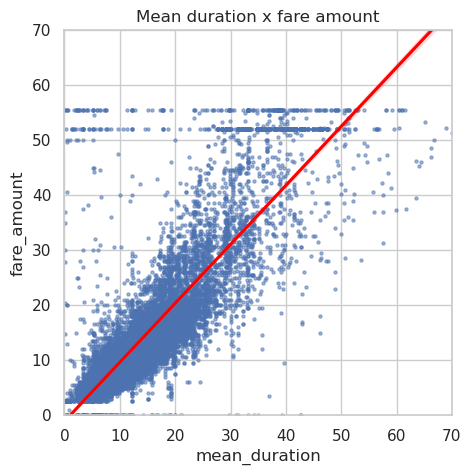

In [36]:
sns.set(style='whitegrid')
f = plt.figure()
f.set_figwidth(5)
f.set_figheight(5)
sns.regplot(x=reduced_df['mean_duration'], y=reduced_df['fare_amount'],
            scatter_kws={'alpha':0.5, 's':5},
            line_kws={'color':'red'})
plt.ylim(0, 70)
plt.xlim(0, 70)
plt.title('Mean duration x fare amount')
plt.show()

In [37]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               25000 non-null  int64         
 1   tpep_pickup_datetime   25000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  25000 non-null  datetime64[us]
 3   passenger_count        25000 non-null  float64       
 4   trip_distance          25000 non-null  float64       
 5   RatecodeID             25000 non-null  float64       
 6   store_and_fwd_flag     25000 non-null  object        
 7   PULocationID           25000 non-null  int64         
 8   DOLocationID           25000 non-null  int64         
 9   payment_type           25000 non-null  int64         
 10  fare_amount            25000 non-null  float64       
 11  extra                  25000 non-null  float64       
 12  mta_tax                25000 non-null  float64       
 13 

In [39]:
rdDf = reduced_df.copy()

rdDf = rdDf.drop(['tpep_dropoff_datetime', 'tpep_pickup_datetime',
               'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
               'payment_type', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge','airport_fee',
               'total_amount', 'tpep_dropoff_datetime', 'tpep_pickup_datetime', 'duration',"congestion_surcharge","pickDrop","dd","mm"
               ], axis=1)
# filling missing values for passsenger count
# rdDf['passenger_count'].fillna(1, inplace=True)

rdDf.info()


<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         25000 non-null  int64  
 1   passenger_count  25000 non-null  float64
 2   fare_amount      25000 non-null  float64
 3   mean_dis         25000 non-null  float64
 4   mean_duration    25000 non-null  float64
 5   peek_t           25000 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 1.3 MB


In [40]:
rdDf.corr(method='pearson')

,VendorID,passenger_count,fare_amount,mean_dis,mean_duration,peek_t
VendorID,1.000000,0.129279,0.003147,0.019076,-0.001180,-0.005573
passenger_count,0.129279,1.000000,0.014733,0.013765,0.008318,-0.035489
fare_amount,0.003147,0.014733,1.000000,0.912105,0.853176,-0.024326
mean_dis,0.019076,0.013765,0.912105,1.000000,0.860656,-0.028520
mean_duration,-0.001180,0.008318,0.853176,0.860656,1.000000,-0.013320
peek_t,-0.005573,-0.035489,-0.024326,-0.028520,-0.013320,1.000000


## Strongest Correlations:

- fare_amount with mean_dis (0.89)
- fare_amount with mean_duration (0.86)
- mean_dis with mean_duration (0.88)


diffrentiating X and y which is features and target

In [41]:

X = rdDf.drop(columns=['fare_amount'])

y = rdDf[['fare_amount']]

# Display first few rows
X.head()

,VendorID,passenger_count,mean_dis,mean_duration,peek_t
1298294,1,1.0,1.546667,7.765972,1
469658,1,2.0,1.302727,8.565909,0
1188324,1,1.0,3.940000,10.975000,1
1508389,2,1.0,6.105000,17.641667,1
824431,1,1.0,0.965435,7.788768,1


In [42]:
X['VendorID'] = X['VendorID'].astype(str)

X = pd.get_dummies(X, drop_first=True)
# X = X.drop(columns=['VendorID_6'])
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   passenger_count  25000 non-null  float64
 1   mean_dis         25000 non-null  float64
 2   mean_duration    25000 non-null  float64
 3   peek_t           25000 non-null  int64  
 4   VendorID_2       25000 non-null  bool   
dtypes: bool(1), float64(3), int64(1)
memory usage: 1001.0 KB


In [199]:
model = RandomForestRegressor()

# Fit the model
model.fit(X, y)

# Get feature importances
importances = model.feature_importances_

# Create a DataFrame for visualization
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
k = 10
selected_features = feature_importances['Feature'].head(k)
X_reduced = X[selected_features]
print(selected_features)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


1           mean_dis
2      mean_duration
0    passenger_count
3             peek_t
4         VendorID_2
Name: Feature, dtype: object


## Training the data Linear regression
- Feature data set is -> VendorID	passenger_count	mean_dis	mean_duration	peek_t
- Target value is fare_amount

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [44]:

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
# X_train_scaled = np.insert(X_train_scaled, 0, 1, axis=1)
print('X_train scaled:', X_train_scaled)
X_train.info()
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)


X_train scaled: [[ 0.61041912 -0.34737175 -0.24074472 -0.67396452  0.65972344]
 [-0.40264058  0.50941772  1.47511678 -0.67396452 -1.51578667]
 [-0.40264058  0.54256951  0.76594123  1.48375764  0.65972344]
 ...
 [-0.40264058  0.12604708  0.69556747  1.48375764  0.65972344]
 [-0.40264058 -0.57920757 -0.97111771 -0.67396452  0.65972344]
 [-0.40264058 -0.55175167 -0.74245957  1.48375764 -1.51578667]]
<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 2351524 to 1558322
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   passenger_count  20000 non-null  float64
 1   mean_dis         20000 non-null  float64
 2   mean_duration    20000 non-null  float64
 3   peek_t           20000 non-null  int64  
 4   VendorID_2       20000 non-null  bool   
dtypes: bool(1), float64(3), int64(1)
memory usage: 800.8 KB


In [45]:
lr=LinearRegression()
lr.fit(X_train_poly, y_train)


LinearRegression()

In [46]:
r_sq = lr.score(X_train_poly, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(X_train_poly)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.8516042452949691
R^2: 0.8516042452949691
MAE: 1.9903578391017913
MSE: 17.564516767177302
RMSE: 4.191004267138999


In [47]:
X_test_scaled = scaler.transform(X_test)
# X_test_scaled = np.insert(X_test_scaled, 0, 1, axis=1)
X_test_poly = poly.transform(X_test_scaled)

In [48]:
r_sq_test = lr.score(X_test_poly, y_test)
print('Coefficient of determination:', r_sq_test)
y_pred_test = lr.predict(X_test_poly)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test,y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coefficient of determination: 0.8742326390091082
R^2: 0.8742326390091082
MAE: 1.8863966267881391
MSE: 14.948803713718371
RMSE: 3.8663682848014327


Reduced MSE: 38.9300723742652


In [312]:
# import statsmodels.api as sm
# scale = StandardScaler()
# y1 = rdDf[['fare_amount']]
# X1 = rdDf.drop(columns=['fare_amount'])
# X1['VendorID'] = X1['VendorID'].astype(int)
# X1[['VendorID','passenger_count', 'mean_dis','mean_duration','peek_t']] = scale.fit_transform(X1[[ 'VendorID','passenger_count', 'mean_dis','mean_duration','peek_t']].values)
# X1 = sm.add_constant(X1)

# # print (X)
# est = sm.OLS(y1, X1).fit()

# print(est.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                 2.210e+04
Date:                Thu, 18 Jul 2024   Prob (F-statistic):               0.00
Time:                        15:45:00   Log-Likelihood:                -78279.
No. Observations:               25000   AIC:                         1.566e+05
Df Residuals:                   24994   BIC:                         1.566e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              17.1591      0.035    4

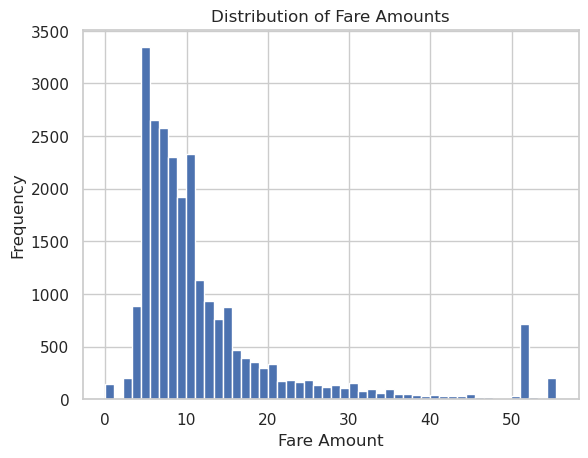

In [49]:

plt.hist(rdDf['fare_amount'], bins=50)
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Amounts')
plt.show()

In [50]:
results = pd.DataFrame(data={'actual': y_test['fare_amount'],
                             'predicted': y_pred_test.ravel()})
results['residual'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,residual
199184,18.0,18.145419,-0.145419
1551566,6.5,7.961860,-1.461860
254730,5.0,7.246101,-2.246101
1209494,12.5,13.470030,-0.970030
1383344,7.5,7.240212,0.259788


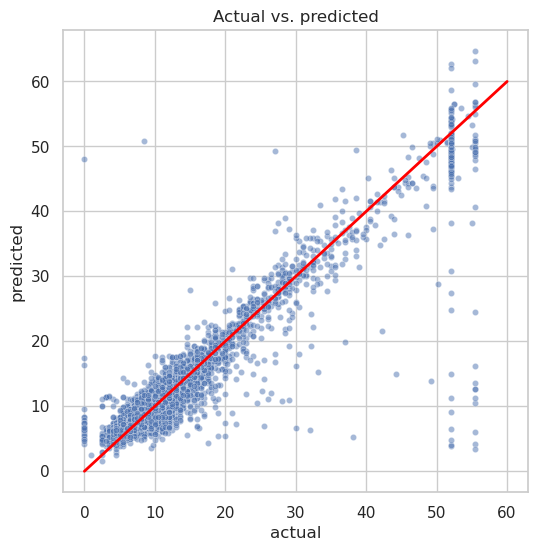

In [51]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.set(style='whitegrid')
sns.scatterplot(x='actual',
                y='predicted',
                data=results,
                s=20,
                alpha=0.5,
                ax=ax
)
plt.plot([0,60], [0,60], c='red', linewidth=2)
plt.title('Actual vs. predicted');

In [52]:
results['residual'].mean()

0.009212661877632146

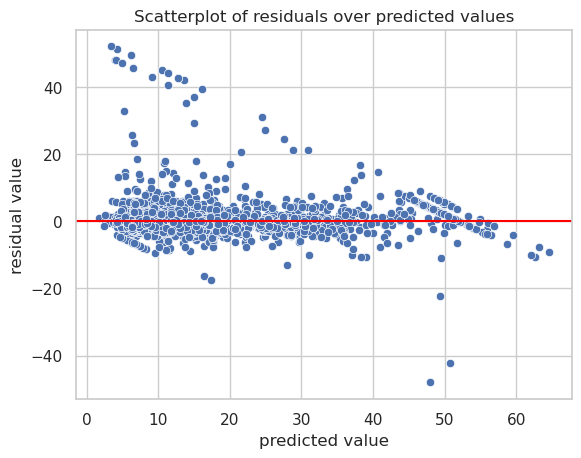

In [53]:
sns.scatterplot(x='predicted', y='residual', data=results)
plt.axhline(0, c='red')
plt.title('Scatterplot of residuals over predicted values')
plt.xlabel('predicted value')
plt.ylabel('residual value')
plt.show()

In [359]:
# coefficients = pd.DataFrame(lr.coef_, columns=X.columns)
# coefficients
feature_names_with_constant = ['constant'] + X.columns.tolist()

# Create the DataFrame for coefficients
coefficients = pd.DataFrame(lr.coef_, columns=feature_names_with_constant)

print(coefficients)

   constant  passenger_count  mean_dis  mean_duration  peek_t  VendorID_2  \
0      0.00             0.25      7.94           4.01    0.02        0.14   

   VendorID_6  
0        0.10  


In [54]:
print(X_train['mean_dis'].std())


print(11.24 / X_train['mean_dis'].std())
rdDf[rdDf['fare_amount'] == 30][:1]

3.921455490136626
2.866282692299127


,VendorID,passenger_count,fare_amount,mean_dis,mean_duration,peek_t
918516,2,2.0,30.0,11.732727,31.515152,1


In [40]:
scaled = scaler.transform([[2,1.00,0.20,1.84,0]])
# 	VendorID	passenger_count	fare_amount	mean_dis	mean_duration	peek_t
feature_names = ['VendorID', 'passenger_count', 'mean_dis', 'mean_duration', 'peek_t']
res = pd.DataFrame(scaled,columns=feature_names)
# res.insert(0, 'constant', 1)
# scaled = np.insert(scaled[0], 0, 1) #Need to add that constant column in again.
print(res)

predicted = lr.predict(res)
print(predicted)

   VendorID  passenger_count  mean_dis  mean_duration  peek_t
0      0.82            -0.66     -1.50           3.28   -1.71
[[5.96949126]]


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [69]:
import boto3

# Create a SageMaker client
sagemaker_client = boto3.client('sagemaker')

# Describe the notebook instance
response = sagemaker_client.describe_notebook_instance(NotebookInstanceName='CFNNotebookInstance-Xa92mgFXrAj5')

# Get the execution role ARN
role_arn = response['RoleArn']
print(role_arn)

arn:aws:iam::765548118789:role/c124716a3072539l7097115t1w76-SageMakerExecutionRole-eW4tRf9IjD2S


In [86]:
import joblib
import tarfile
import boto3


# Create a tar.gz archive
with tarfile.open('lr.tar.gz', 'w:gz') as tar:
    tar.add('lr.joblib', arcname='lr.joblib')


s3 = boto3.client('s3')
s3.upload_file('lr.tar.gz', 'cml1550', 'lr.tar.gz')
# Save the model to S3
# s3 = boto3.client('s3')
# joblib.dump(lr, 'lr.joblib')
# s3.upload_file('lr.joblib', 'cml1550', 'lr.joblib')

In [109]:
import sagemaker
from sagemaker.sklearn import SKLearnModel

role = 'arn:aws:iam::765548118789:role/c124716a3072539l7097115t1w76-SageMakerExecutionRole-eW4tRf9IjD2S'
framework_version = '0.23-1'
py_version = 'py3'

model = SKLearnModel(model_data='s3://cml1550/lr.joblib',
                     role=role,
                     entry_point='inference.py',framework_version=framework_version,
                     py_version=py_version)  # Your inference script
print(model)

In [ ]:
predictor = model.deploy(initial_instance_count=1, instance_type='ml.m4.xlarge')

----

In [79]:
import json

data = json.dumps([[2,1.00,0.31,4.18,0]])  # Example input data
response = predictor.predict(data)
print(response)

ModelError: An error occurred (ModelError) when calling the InvokeEndpoint operation: Received server error (500) from primary with message "<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<title>500 Internal Server Error</title>
<h1>Internal Server Error</h1>
<p>The server encountered an internal error and was unable to complete your request. Either the server is overloaded or there is an error in the application.</p>
". See https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#logEventViewer:group=/aws/sagemaker/Endpoints/sagemaker-scikit-learn-2024-07-18-06-59-25-340 in account 765548118789 for more information.

In [104]:
import os
def model_fn(model_dir):
    model = joblib.load(os.path.join(model_dir, 'lr.joblib'))
    return model
print(os.path)

<module 'posixpath' from '/home/ec2-user/anaconda3/envs/python3/lib/python3.10/posixpath.py'>


In [103]:
model_fn('CML_CA')

FileNotFoundError: [Errno 2] No such file or directory: 'CML_CA/lr.joblib'

## Random Forest Algorithm

In [49]:
# X1 = rdDf.drop(columns=['fare_amount'])

# y1 = rdDf[['fare_amount']]
# Separating features and target variable
# X = df[['passenger_count', 'mean_dis', 'mean_duration', 'peek_t', 'VendorID_2']]
# y = df['fare_amount']

# # Splitting the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Initialize the Random Forest Regressor
# rf = RandomForestRegressor(n_estimators=100, random_state=42)

# # Train the model
# rf.fit(X_train, y_train)

# # Make predictions
# y_pred = rf.predict(X_test)

# # Evaluate the model
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f'Mean Squared Error: {mse}')
# print(f'R^2 Score: {r2}')

# # Optionally, you can print feature importances
# importances = rf.feature_importances_
# feature_names = X.columns
# feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# print(feature_importance_df.sort_values(by='Importance', ascending=False))

### Changing VendorID to vendorID str

In [52]:
# X1['VendorID'] = X1['VendorID'].astype(str)

# X1 = pd.get_dummies(X1, drop_first=True)
# X1 = X1.drop(columns=['VendorID_6'])
# X1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 270111 to 2668242
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   passenger_count  25000 non-null  float64
 1   mean_dis         25000 non-null  float64
 2   mean_duration    25000 non-null  float64
 3   peek_t           25000 non-null  int64  
 4   VendorID_2       25000 non-null  bool   
dtypes: bool(1), float64(3), int64(1)
memory usage: 1001.0 KB


## Train test function

In [53]:
# X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [55]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [57]:
# # Train the model
rf.fit(X_train_poly, y_train)

# # Make predictions
y_pred1 = rf.predict(X_test_poly)

# # Evaluate the model
mse1 = mean_squared_error(y_test, y_pred1)
r21 = r2_score(y_test, y_pred1)

print(f'Mean Squared Error: {mse1}')
print(f'R^2 Score: {r21}')
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred1)))

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Squared Error: 16.466342465155613
R^2 Score: 0.8614652732971264
RMSE: 4.057874131260802


In [65]:
# # Optionally, you can print feature importances
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
print(feature_importance_df.sort_values(by='Importance', ascending=False))

           Feature  Importance
1         mean_dis        0.83
2    mean_duration        0.13
0  passenger_count        0.02
3           peek_t        0.01
4       VendorID_2        0.01


## XGBoost Algorithm

In [57]:
# X2 = rdDf[['passenger_count', 'mean_dis', 'mean_duration', 'peek_t', 'VendorID']]
# y2 = rdDf['fare_amount']

## Train test dataset

In [58]:
# X_train, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)


In [58]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',  # for regression task
    max_depth=6,                   # maximum depth of a tree
    learning_rate=0.3,             # learning rate
    n_estimators=100,              # number of trees to fit
    subsample=0.8,                 # subsample ratio of the training instances
    colsample_bytree=0.8,          # subsample ratio of columns when constructing each tree
    random_state=42
)

In [60]:
# Train the model
xgb_model.fit(X_train_poly, y_train)

# Make predictions
y_pred2 = xgb_model.predict(X_test_poly)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred2)
r2 = r2_score(y_test, y_pred2)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred2)))
# Optionally, you can print feature importances
# importances = xgb_model.feature_importances_
# feature_names = X.columns
# feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# print(feature_importance_df.sort_values(by='Importance', ascending=False))

Mean Squared Error: 15.6139256009934
R^2 Score: 0.8686368465423584
RMSE: 3.951446013928749


In [61]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
predictions = [y_pred_test, y_pred1, y_pred2]

for model_name, pred in zip(models, predictions):
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f'{model_name} - Mean Squared Error: {mse}, R^2 Score: {r2}')

Linear Regression - Mean Squared Error: 14.948803713718371, R^2 Score: 0.8742326390091082
Random Forest - Mean Squared Error: 16.466342465155613, R^2 Score: 0.8614652732971264
XGBoost - Mean Squared Error: 15.6139256009934, R^2 Score: 0.8686368465423584


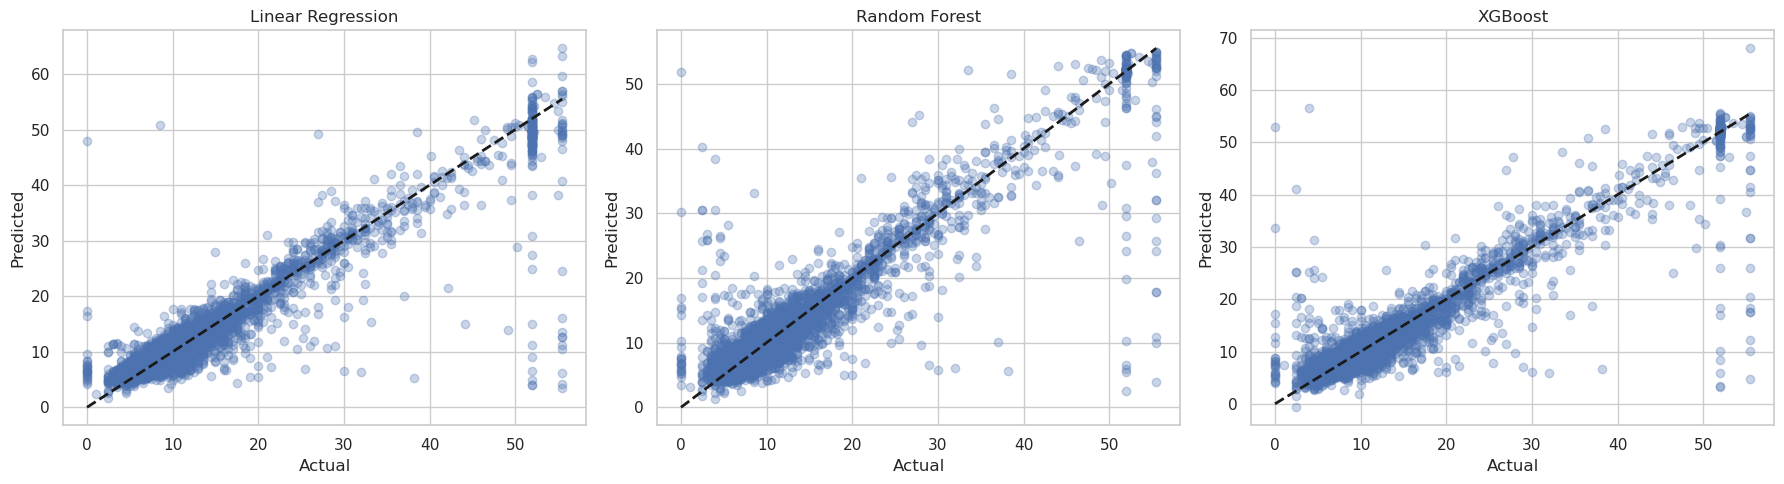

In [62]:
plt.figure(figsize=(18, 5))

# Plot Linear Regression results
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression')

# Plot Random Forest results
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred1, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest')

# Plot XGBoost results
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred2, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost')

plt.tight_layout()
plt.show()